<a href="https://colab.research.google.com/github/Chaitralikore/Remote-Sensing/blob/main/4_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr

In [2]:
# Step 1: Read the image and print the shape
image = cv2.imread('/content/drive/MyDrive/LAB/4image_denoising/earthFromSpace_NASA.jpg')  # Replace with the path to your image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for plotting
print("Image Shape:", image.shape)

Image Shape: (512, 512, 3)


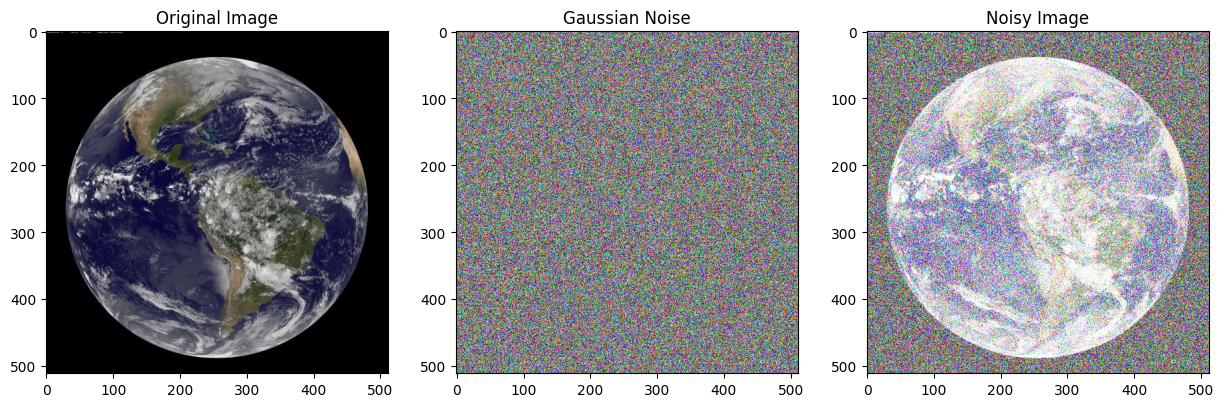

In [3]:
# Step 2: Generate random Gaussian noise and add it to the image
mean = 0
stddev = 180
gaussian_noise = np.random.normal(mean, stddev, image.shape).astype(np.uint8)

noisy_image_gaussian = cv2.add(image, gaussian_noise)

# Step 3: Plot the original image, Gaussian noise, and noisy image
plt.figure(figsize=(15, 5))

# Plot Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')

# Plot Gaussian Noise
plt.subplot(1, 3, 2)
plt.imshow(gaussian_noise)
plt.title('Gaussian Noise')

# Plot Noisy Image
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(noisy_image_gaussian, cv2.COLOR_BGR2RGB))
plt.title('Noisy Image')

plt.show()



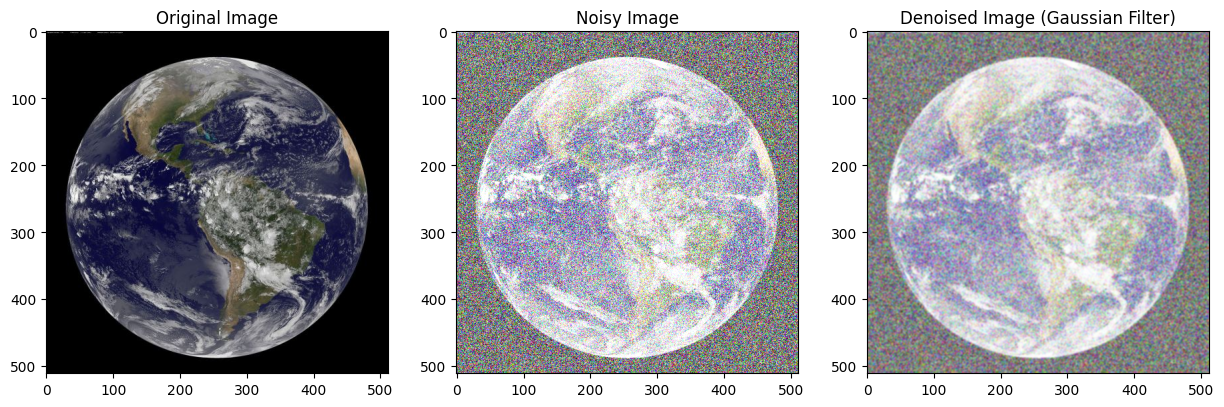

In [4]:
# Step 4: Denoise the noisy image using a Gaussian filter
denoised_image_gaussian = cv2.GaussianBlur(noisy_image_gaussian, (5, 5), 0)

# Step 5: Plot original, noisy, and denoised images using Gaussian filter
plt.figure(figsize=(15, 5))

# Plot Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')

# Plot Noisy Image
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(noisy_image_gaussian, cv2.COLOR_BGR2RGB))
plt.title('Noisy Image')

# Plot Denoised Image with Gaussian Filter
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(denoised_image_gaussian, cv2.COLOR_BGR2RGB))
plt.title('Denoised Image (Gaussian Filter)')

plt.show()



PSNR (Gaussian Filter): 6.65 dB


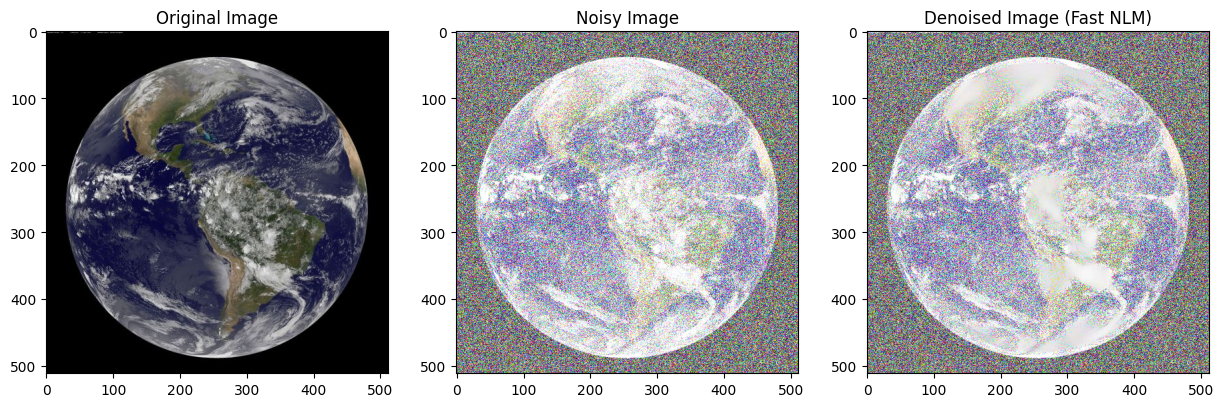

PSNR (Fast NLM): 5.69 dB


In [5]:
# Step 6: Compute PSNR (dB) for Gaussian filter denoising
psnr_gaussian = psnr(image, denoised_image_gaussian)
print(f'PSNR (Gaussian Filter): {psnr_gaussian:.2f} dB')

# Step 7: Denoising the noisy image using Fast NLM (Non-Local Means) Denoising
denoised_image_nlmeans = cv2.fastNlMeansDenoisingColored(noisy_image_gaussian, None, 10, 7, 21)

# Step 8: Plot original, noisy, and denoised images using Fast NLM Denoising
plt.figure(figsize=(15, 5))

# Plot Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')

# Plot Noisy Image
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(noisy_image_gaussian, cv2.COLOR_BGR2RGB))
plt.title('Noisy Image')

# Plot Denoised Image with Fast NLM
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(denoised_image_nlmeans, cv2.COLOR_BGR2RGB))
plt.title('Denoised Image (Fast NLM)')

plt.show()

# Step 9: Compute PSNR (dB) for Fast NLM denoising
psnr_nlmeans = psnr(image, denoised_image_nlmeans)
print(f'PSNR (Fast NLM): {psnr_nlmeans:.2f} dB')



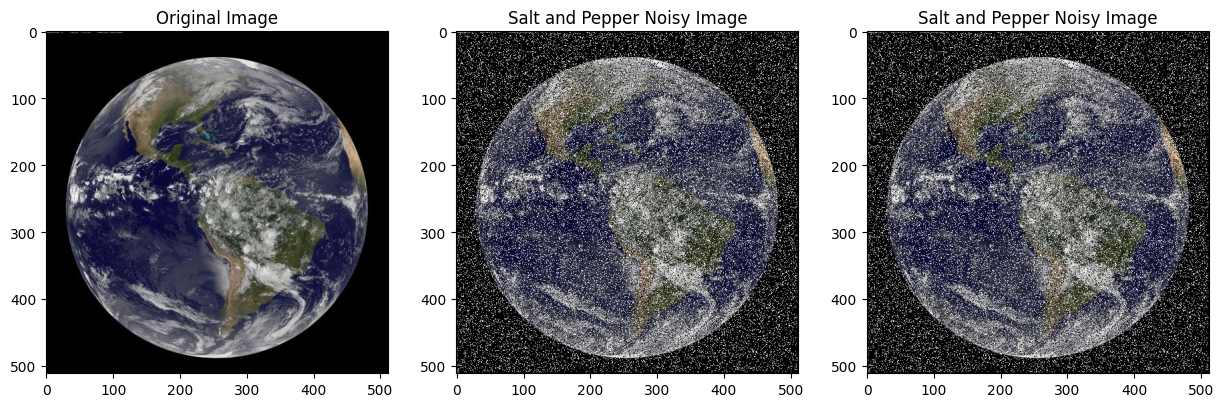

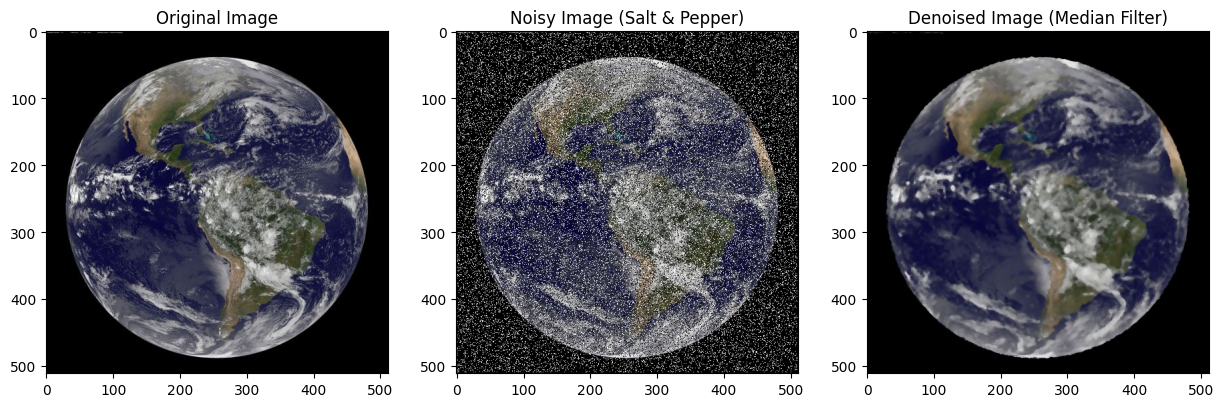

PSNR (Median Filter): 25.09 dB


In [6]:
# Step 10: Generate Salt and Pepper Noise (Impulse Noise)
def add_salt_and_pepper(image, salt_prob, pepper_prob):
    noisy_image = image.copy()
    total_pixels = image.size
    num_salt = int(salt_prob * total_pixels)
    num_pepper = int(pepper_prob * total_pixels)

    # Add Salt noise
    salt_coords = [np.random.randint(0, i-1, num_salt) for i in image.shape]
    noisy_image[salt_coords[0], salt_coords[1], :] = 255

    # Add Pepper noise
    pepper_coords = [np.random.randint(0, i-1, num_pepper) for i in image.shape]
    noisy_image[pepper_coords[0], pepper_coords[1], :] = 0

    return noisy_image

salt_pepper_noise_image = add_salt_and_pepper(image, salt_prob=0.05, pepper_prob=0.05)

# Step 11: Plot original image, salt & pepper noisy image, and noisy image
plt.figure(figsize=(15, 5))

# Plot Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')

# Plot Salt and Pepper Noisy Image
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(salt_pepper_noise_image, cv2.COLOR_BGR2RGB))
plt.title('Salt and Pepper Noisy Image')

# Plot Noisy Image
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(salt_pepper_noise_image, cv2.COLOR_BGR2RGB))
plt.title('Salt and Pepper Noisy Image')

plt.show()

# Step 12: Denoising the Salt and Pepper Noisy Image using Median Filter
denoised_image_median = cv2.medianBlur(salt_pepper_noise_image, 5)

# Step 13: Plot original, noisy, and denoised images using Median Filter
plt.figure(figsize=(15, 5))

# Plot Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')

# Plot Noisy Image
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(salt_pepper_noise_image, cv2.COLOR_BGR2RGB))
plt.title('Noisy Image (Salt & Pepper)')

# Plot Denoised Image with Median Filter
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(denoised_image_median, cv2.COLOR_BGR2RGB))
plt.title('Denoised Image (Median Filter)')

plt.show()

# Step 14: Compute PSNR (dB) for Median Filter denoising
psnr_median = psnr(image, denoised_image_median)
print(f'PSNR (Median Filter): {psnr_median:.2f} dB')



In [7]:
# Step 15: Compare Denoised Images with PSNR values
print(f'PSNR Comparison:')
print(f'Gaussian Filter PSNR: {psnr_gaussian:.2f} dB')
print(f'Fast NLM PSNR: {psnr_nlmeans:.2f} dB')
print(f'Median Filter PSNR: {psnr_median:.2f} dB')

PSNR Comparison:
Gaussian Filter PSNR: 6.65 dB
Fast NLM PSNR: 5.69 dB
Median Filter PSNR: 25.09 dB
